In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("data\\train.csv")
val_df = pd.read_csv("data\\train.csv")

In [3]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_val = vectorizer.transform(val_df['full_name'])

y_train = train_df['label']
y_val = val_df['label']

In [ ]:
svc = SVC(random_state = 42, C = 10, gamma = 1)
svc.fit(X_train, y_train)
predicted_y = svc.predict(X_val)

In [ ]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 95.34777502283701
Recall: 99.25088049494065
Precision: 92.06741573033707
f1_score: 95.52428864796033

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     53619
           1       0.92      0.99      0.96     53663

    accuracy                           0.95    107282
   macro avg       0.96      0.95      0.95    107282
weighted avg       0.96      0.95      0.95    107282



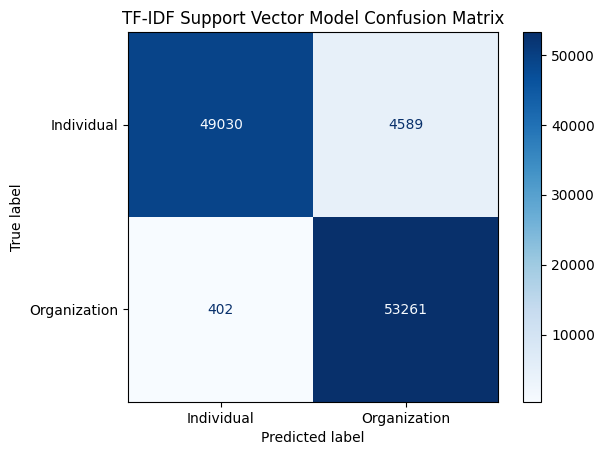

In [6]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Support Vector Model Confusion Matrix')
#plt.savefig('TF-IDF Support Vector Model Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [ ]:
test_df = pd.read_csv("data\\test.csv")
X_test = vectorizer.transform(test_df['full_name'])
y_test = train_df['label']

In [ ]:
predicted_y_test = svc.predict(X_test)
print(classification_report(y_test, predicted_y_test))

In [7]:
# from sklearn.model_selection import GridSearchCV 

# param_grid = {'C': [0.1, 1, 10, 100, 1000], 
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
# 			'kernel': ['rbf']} 

# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
 
# grid.fit(X_train, y_train)

In [8]:
# print(grid.best_params_) 
 
# print(grid.best_estimator_)

In [9]:
# grid_predictions = grid.predict(y_val) 

# print(classification_report(y_val, grid_predictions))